In [1]:
!pip -q install torch torchvision matplotlib pillow opencv-python

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

In [3]:
print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [5]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 14.90 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [6]:
%cd pytorch-CycleGAN-and-pix2pix

/content/pytorch-CycleGAN-and-pix2pix


In [7]:
!bash scripts/download_pix2pix_model.sh facades_label2photo

Note: available models are edges2shoes, sat2map, map2sat, facades_label2photo, and day2night
Specified [facades_label2photo]
for details.

--2026-07-10 14:34:53--  http://efrosgans.eecs.berkeley.edu/pix2pix/models-pytorch/facades_label2photo.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 217704720 (208M)
Saving to: ‘./checkpoints/facades_label2photo_pretrained/latest_net_G.pth’

./checkpoints/facad 100%[===================>] 207.62M  60.4MB/s    in 3.5s    

2026-07-10 14:34:56 (58.5 MB/s) - ‘./checkpoints/facades_label2photo_pretrained/latest_net_G.pth’ saved [217704720/217704720]



In [8]:
!bash datasets/download_pix2pix_dataset.sh facades

Specified [facades]
for details.

--2026-07-10 14:35:52--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘./datasets/facades.tar.gz’

./datasets/facades. 100%[===================>]  28.77M  6.47MB/s    in 6.5s    

2026-07-10 14:35:58 (4.42 MB/s) - ‘./datasets/facades.tar.gz’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/1

In [10]:
!pip install dominate visdom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=225aed5446ea8f159c817bb89fcf2365cdfdc774eba388c1c6ff7cc1b6845814
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


In [11]:
!python test.py \
  --dataroot ./datasets/facades \
  --name facades_label2photo_pretrained \
  --model pix2pix \
  --direction BtoA \
  --results_dir ./results \
  --num_test 10

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/facades            	[default: None]
             dataset_mode: aligned                       
                direction: BtoA                          	[default: AtoB]
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 

Generated Images:



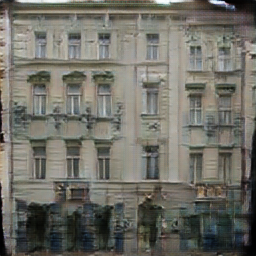

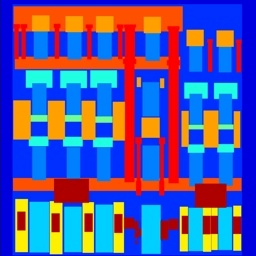

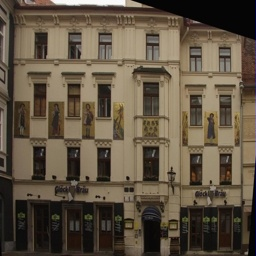

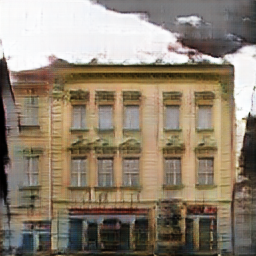

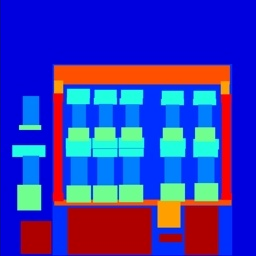

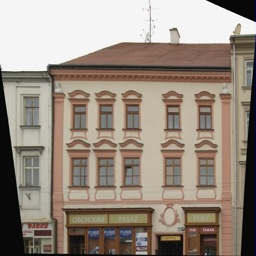

In [12]:
import os
from IPython.display import Image, display

result_dir = "./results/facades_label2photo_pretrained/test_latest/images"

print("Generated Images:\n")

for img in sorted(os.listdir(result_dir))[:6]:
    display(Image(filename=os.path.join(result_dir, img)))

In [13]:
import os

result_dir = "./results/facades_label2photo_pretrained/test_latest/images"

print("Output Files:\n")
for file in sorted(os.listdir(result_dir)):
    print(file)

Output Files:

100_fake_B.png
100_real_A.png
100_real_B.png
101_fake_B.png
101_real_A.png
101_real_B.png
102_fake_B.png
102_real_A.png
102_real_B.png
103_fake_B.png
103_real_A.png
103_real_B.png
104_fake_B.png
104_real_A.png
104_real_B.png
105_fake_B.png
105_real_A.png
105_real_B.png
106_fake_B.png
106_real_A.png
106_real_B.png
10_fake_B.png
10_real_A.png
10_real_B.png
11_fake_B.png
11_real_A.png
11_real_B.png
1_fake_B.png
1_real_A.png
1_real_B.png


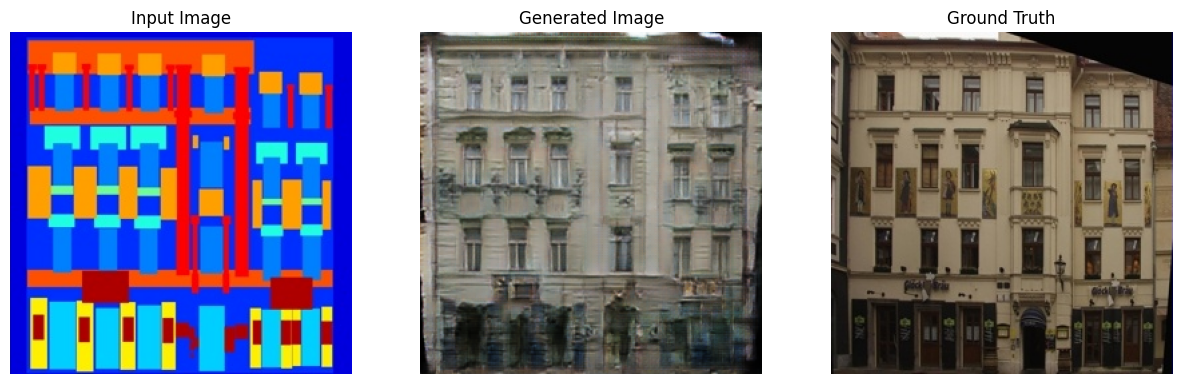

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

result_dir = "./results/facades_label2photo_pretrained/test_latest/images"

sample = "100"

real_A = Image.open(os.path.join(result_dir, f"{sample}_real_A.png"))
fake_B = Image.open(os.path.join(result_dir, f"{sample}_fake_B.png"))
real_B = Image.open(os.path.join(result_dir, f"{sample}_real_B.png"))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(real_A)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(fake_B)
plt.title("Generated Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(real_B)
plt.title("Ground Truth")
plt.axis("off")

plt.show()